In [1]:
!pip install --upgrade --no-cache-dir gdown
!gdown 1SZZrpCgW8fI85m-_RpCygNuapWH3l0Vj

  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2
Downloading...
From (original): https://drive.google.com/uc?id=1SZZrpCgW8fI85m-_RpCygNuapWH3l0Vj
From (redirected): https://drive.google.com/uc?id=1SZZrpCgW8fI85m-_RpCygNuapWH3l0Vj&confirm=t&uuid=e8f3779c-a549-4d9b-9b25-94c048f4f5ab
To: /content/archive.zip
100% 27.6M/27.6M [00:00<00:00, 31.0MB/s]


#1) Setup

In [2]:
!pip install timm -q

In [3]:
import os
import random
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

#2) Dataset paths

In [4]:
!unzip -q archive.zip -d /content/dataset

In [5]:
ROOT = Path("/content/dataset/NEU-DET")
IMG_DIR = ROOT / "IMAGES"
ANN_DIR = ROOT / "ANNOTATIONS"

print("Images:", len(list(IMG_DIR.glob("*.jpg"))))
print("Annotations:", len(list(ANN_DIR.glob("*.xml"))))

Images: 1800
Annotations: 1800


#3) Reading labels from XML

In [6]:
def parse_voc_xml_for_classification(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text.strip()

    if not filename.lower().endswith((".jpg", ".jpeg", ".png")):
        filename += ".jpg"

    labels = []

    for obj in root.findall("object"):
        label = obj.find("name").text.strip()
        labels.append(label)

    return filename, labels

#4) Creating a classification dataset

In [7]:
CLS_ROOT = Path("/content/neu_classification")

if CLS_ROOT.exists():
    shutil.rmtree(CLS_ROOT)

for split in ["train", "val", "test"]:
    (CLS_ROOT / split).mkdir(parents=True, exist_ok=True)

In [8]:
samples = []

for xml_path in ANN_DIR.glob("*.xml"):
    filename, labels = parse_voc_xml_for_classification(xml_path)

    if len(labels) == 0:
        continue

    img_path = IMG_DIR / filename

    if not img_path.exists():
        continue

    # Most NEU-DET images contain defects from one class.
    label = labels[0]

    samples.append((img_path, label))

print("Total samples:", len(samples))
print(samples[:5])

Total samples: 1800
[(PosixPath('/content/dataset/NEU-DET/IMAGES/rolled-in_scale_92.jpg'), 'rolled-in_scale'), (PosixPath('/content/dataset/NEU-DET/IMAGES/rolled-in_scale_264.jpg'), 'rolled-in_scale'), (PosixPath('/content/dataset/NEU-DET/IMAGES/patches_191.jpg'), 'patches'), (PosixPath('/content/dataset/NEU-DET/IMAGES/scratches_6.jpg'), 'scratches'), (PosixPath('/content/dataset/NEU-DET/IMAGES/rolled-in_scale_205.jpg'), 'rolled-in_scale')]


#5) Stratified split

In [9]:
from collections import defaultdict

by_class = defaultdict(list)

for img_path, label in samples:
    by_class[label].append((img_path, label))

train_samples, val_samples, test_samples = [], [], []

random.seed(42)

for label, items in by_class.items():
    random.shuffle(items)
    n = len(items)

    train_samples.extend(items[:int(0.7*n)])
    val_samples.extend(items[int(0.7*n):int(0.85*n)])
    test_samples.extend(items[int(0.85*n):])

print("Train:", len(train_samples))
print("Val:", len(val_samples))
print("Test:", len(test_samples))

Train: 1260
Val: 270
Test: 270


In [10]:
splits = {
    "train": train_samples,
    "val": val_samples,
    "test": test_samples
}

for split, split_samples in splits.items():
    for img_path, label in split_samples:
        class_dir = CLS_ROOT / split / label
        class_dir.mkdir(parents=True, exist_ok=True)

        dst = class_dir / img_path.name
        shutil.copy(img_path, dst)

In [11]:
!find /content/neu_classification -maxdepth 2 -type d

/content/neu_classification
/content/neu_classification/train
/content/neu_classification/train/rolled-in_scale
/content/neu_classification/train/pitted_surface
/content/neu_classification/train/scratches
/content/neu_classification/train/crazing
/content/neu_classification/train/inclusion
/content/neu_classification/train/patches
/content/neu_classification/test
/content/neu_classification/test/rolled-in_scale
/content/neu_classification/test/pitted_surface
/content/neu_classification/test/scratches
/content/neu_classification/test/crazing
/content/neu_classification/test/inclusion
/content/neu_classification/test/patches
/content/neu_classification/val
/content/neu_classification/val/rolled-in_scale
/content/neu_classification/val/pitted_surface
/content/neu_classification/val/scratches
/content/neu_classification/val/crazing
/content/neu_classification/val/inclusion
/content/neu_classification/val/patches


#6) GPU check

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda
Tesla T4


#7) Transforms

In [18]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

#8) Dataset and Loader

In [19]:
train_dataset = datasets.ImageFolder(CLS_ROOT / "train", transform=train_transform)
val_dataset = datasets.ImageFolder(CLS_ROOT / "val", transform=eval_transform)
test_dataset = datasets.ImageFolder(CLS_ROOT / "test", transform=eval_transform)

class_names = train_dataset.classes
num_classes = len(class_names)

print(class_names)

['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [20]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

#9) EfficientNet-B0

In [21]:
weights = EfficientNet_B0_Weights.DEFAULT
model = efficientnet_b0(weights=weights)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

model = model.to(device)

In [22]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.classifier.parameters(), lr=1e-3)

#10) Train / Eval functions

In [23]:
def train_one_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

In [24]:
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    y_true, y_pred = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    return total_loss / total, correct / total, y_true, y_pred

#11) Train

In [25]:
best_val_acc = 0
best_model_path = "/content/efficientnet_b0_neu_classification.pt"

epochs = 5

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc, _, _ = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print("-" * 40)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

print("Best Val Accuracy:", best_val_acc)

Epoch 1/5
Train Loss: 1.1439 | Train Acc: 0.7675
Val Loss:   0.9362 | Val Acc:   0.8333
----------------------------------------
Epoch 2/5
Train Loss: 0.4665 | Train Acc: 0.9405
Val Loss:   0.4463 | Val Acc:   0.9630
----------------------------------------
Epoch 3/5
Train Loss: 0.2949 | Train Acc: 0.9548
Val Loss:   0.2509 | Val Acc:   0.9704
----------------------------------------
Epoch 4/5
Train Loss: 0.2262 | Train Acc: 0.9603
Val Loss:   0.1735 | Val Acc:   0.9852
----------------------------------------
Epoch 5/5
Train Loss: 0.1839 | Train Acc: 0.9667
Val Loss:   0.1443 | Val Acc:   0.9852
----------------------------------------
Best Val Accuracy: 0.9851851851851852


#12) Test

In [26]:
model.load_state_dict(torch.load(best_model_path))
model = model.to(device)

test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.9851851851851852


In [27]:
print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

                 precision    recall  f1-score   support

        crazing     0.9783    1.0000    0.9890        45
      inclusion     0.9565    0.9778    0.9670        45
        patches     1.0000    0.9778    0.9888        45
 pitted_surface     0.9783    1.0000    0.9890        45
rolled-in_scale     1.0000    1.0000    1.0000        45
      scratches     1.0000    0.9556    0.9773        45

       accuracy                         0.9852       270
      macro avg     0.9855    0.9852    0.9852       270
   weighted avg     0.9855    0.9852    0.9852       270



#13) Confusion Matrix

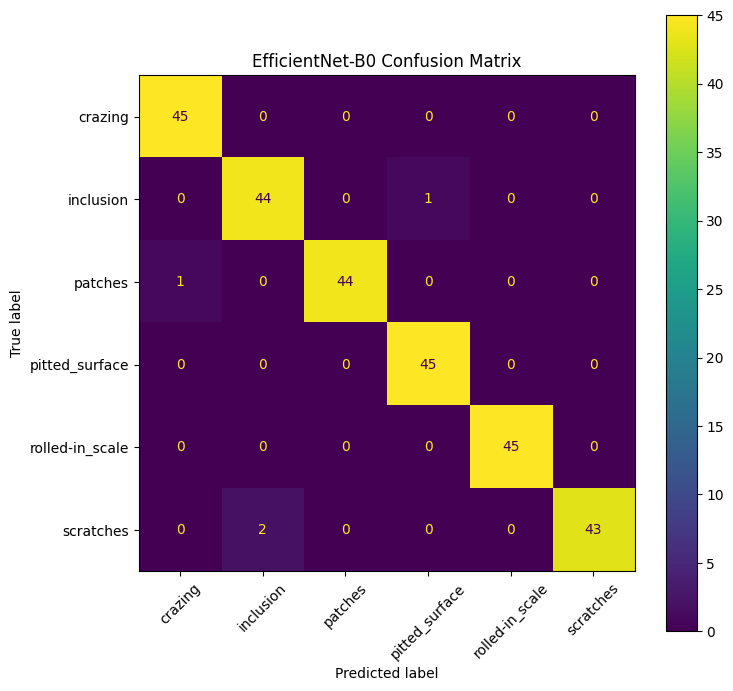

In [28]:
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("EfficientNet-B0 Confusion Matrix")
plt.show()

#14) Save model

In [29]:
from google.colab import files
files.download(best_model_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>